In [1]:
#pip install opencv-Python!
#pip install tensorflow!

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob as gb
import cv2
import tensorflow as tf
import keras

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [163]:
train_path="/content/drive/MyDrive/data/seg_train"
test_path="/content/drive/MyDrive/data/seg_test"
pred_path="/content/drive/MyDrive/data/seg_pred"

In [164]:
print(os.listdir(train_path))

['forest', 'sea', 'mountain', 'glacier', 'street', 'buildings']


In [165]:
for folder in os.listdir(train_path):
  image=gb.glob(pathname=str(train_path+"/"+folder+"/*.jpg"))
  print(f"for the folder {folder} we have {len(image)} images")


for the folder forest we have 70 images
for the folder sea we have 90 images
for the folder mountain we have 60 images
for the folder glacier we have 70 images
for the folder street we have 80 images
for the folder buildings we have 70 images


In [166]:
for folder in os.listdir(test_path):
  image=gb.glob(pathname=str(test_path+"/"+folder+"/*.jpg"))
  print(f"for the folder {folder} we have {len(image)} images")


for the folder buildings we have 100 images
for the folder forest we have 80 images
for the folder sea we have 80 images
for the folder mountain we have 90 images
for the folder street we have 120 images
for the folder glacier we have 90 images


In [167]:
image=gb.glob(pathname=str(pred_path+"/*.jpg" ))
print(f"for the folder {folder} we have {len(image)} images")


for the folder glacier we have 90 images


In [168]:
#size of train data
size=[]
for folder in os.listdir(train_path):
  image=gb.glob(pathname=str(train_path+"/"+folder+"/*.jpg"))
  for img in image:
    img= plt.imread(img)
    size.append(img.shape)


In [169]:
pd.Series(size).value_counts()

,count
"(150, 150, 3)",438
"(140, 150, 3)",1
"(113, 150, 3)",1


In [170]:
#size of test data
size=[]
for folder in os.listdir(test_path):
  image=gb.glob(pathname=str(test_path+"/"+folder+"/*.jpg"))
  for img in image:
    img= plt.imread(img)
    size.append(img.shape)

pd.Series(size).value_counts()

,count
"(150, 150, 3)",560


In [171]:
#size of pred data
size=[]
image=gb.glob(pathname=str(pred_path+"/*.jpg"))
for img in image:
  img= plt.imread(img)
  size.append(img.shape)

pd.Series(size).value_counts()

,count
"(150, 150, 3)",90


In [185]:
code = {'buildings':0 ,'forest':1,'glacier':2,'mountain':3,'sea':4,'street':5}

def get_name(n):
    for k,v in code.items():
      if v==n:
        return k

In [173]:
code['buildings']

0

In [174]:
#split train data
x_train=[]
y_train=[]
for folder in os.listdir(train_path):
  image=gb.glob(pathname=str(train_path+"/"+folder+"/*.jpg"))
  for img in image:
    img= plt.imread(img)
    img=cv2.resize(img,(224,224))
    x_train.append(img)
    y_train.append(code[folder])



In [175]:
#y_train

In [176]:
#split test data
x_test=[]
y_test=[]
for folder in os.listdir(test_path):
  image=gb.glob(pathname=str(test_path+"/"+folder+"/*.jpg"))
  for img in image:
    img= plt.imread(img)
    img=cv2.resize(img,(224,224))
    x_test.append(img)
    y_test.append(code[folder])


In [177]:
# pred data
x_pred=[]
image=gb.glob(pathname=str(pred_path+"/*.jpg"))
for img in image:
  img= plt.imread(img)
  img=cv2.resize(img,(224,224))
  x_pred.append(img)

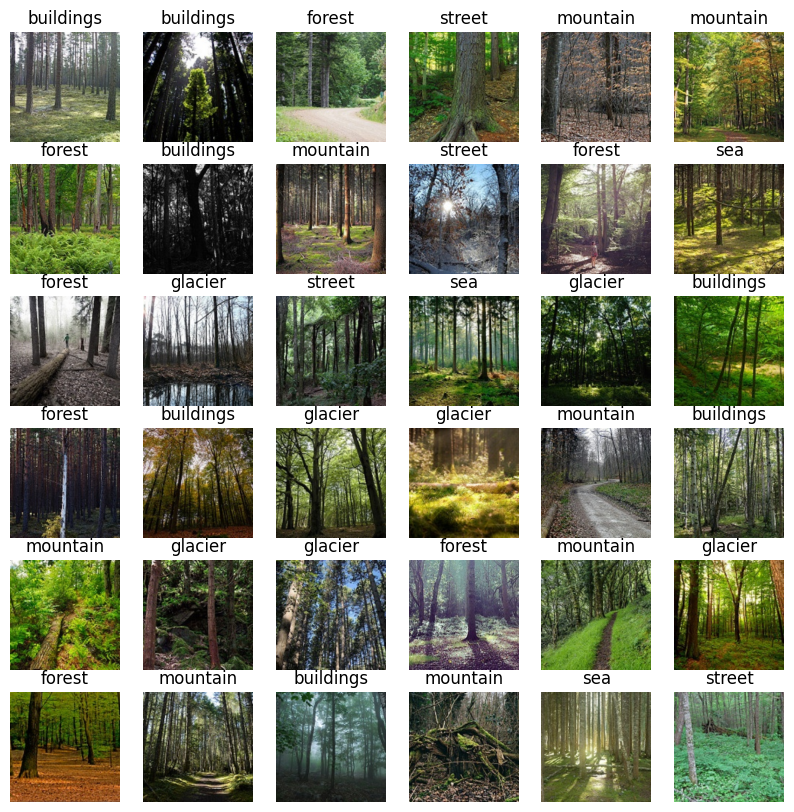

In [186]:
plt.figure(figsize=(10,10))
for i,v in enumerate(np.random.randint(0,len(x_train),36)):
  plt.subplot(6,6,i+1)
  plt.axis("off")
  plt.imshow(x_train[i])
  plt.title(get_name(y_train[v]))

In [179]:
type(x_train)

list

In [180]:
x_train=np.array(x_train)
y_train=np.array(y_train)

x_test=np.array(x_test)
y_test=np.array(y_test)

x_pred=np.array(x_pred)

In [187]:
model= keras.models.Sequential(
    [
        keras.layers.Conv2D(64,kernel_size=(3,3),activation="relu",input_shape=(224,224,3)),
        keras.layers.Conv2D(32,kernel_size=(3,3),activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2,2)),
        keras.layers.Conv2D(64,kernel_size=(3,3),activation="relu"),
        keras.layers.Conv2D(32,kernel_size=(3,3),activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128,activation="relu"),
        keras.layers.Dense(64,activation="relu"),
        keras.layers.Dense(6,activation="softmax")
    ]
)


In [188]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [189]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 220, 220, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 106, 106, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 89888)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,505,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,571,654 (44.14 MB)

 Trainable params: 11,571,654 (44.14 MB)

 Non-trainable params: 0 (0.00 B)

In [191]:
final_model=model.fit(x_train,y_train,epochs=3,batch_size=64,verbose=1)

Epoch 1/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 124s 18s/step - accuracy: 0.2795 - loss: 4.5593
Epoch 2/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 124s 18s/step - accuracy: 0.5614 - loss: 1.1900
Epoch 3/3
7/7 ━━━━━━━━━━━━━━━━━━━━ 124s 18s/step - accuracy: 0.7977 - loss: 0.6259


In [192]:
loss , accuracy = model.evaluate(x_test,y_test)
print(f"the loss is {loss} and the acc = {accuracy}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.2750 - loss: 2.4496
the loss is 2.44964337348938 and the acc = 0.2750000059604645


In [ ]:
from google.colab import drive
drive.mount('/content/drive')